In [ ]:
!pip install contractions
!pip install -q sentence-transformers umap-learn hdbscan
!pip install --quiet KeyBERT
!pip install -U arrow

# IMPORT LIBRARY

In [ ]:
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import BertModel
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
import numpy as np
import re
import nltk
import os
import contractions
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import kagglehub
import os
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import string
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
from transformers import get_scheduler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
from wordcloud import WordCloud, ImageColorGenerator
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import seaborn as sns
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.cluster import KMeans
from keybert import KeyBERT
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sentence_transformers import util
from sklearn.metrics import silhouette_score
import ipywidgets as widgets
from IPython.display import display


nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# Read the Data

In [ ]:
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")
print("Path to dataset files:", path)

#read the data
file_path = os.path.join(path,"Womens Clothing E-Commerce Reviews.csv")
df = pd.read_csv(file_path, encoding="ISO-8859-1")

In [ ]:
df.head()

In [ ]:
#boş yorumlar  ve eksik veriler silinir.
df.dropna(subset=['Review Text'], inplace=True)
df.dropna(subset=['Department Name'], inplace=True)
df = df[df['Review Text'].str.strip() != ""]

stop_words = set(stopwords.words('english'))
punctuations = set(string.punctuation)
lemmatizer = WordNetLemmatizer()

In [ ]:
def get_wordnet_pos(tag):
       if tag.startswith('J'):
         return wordnet.ADJ
       elif tag.startswith('V'):
         return wordnet.VERB
       elif tag.startswith('N'):
         return wordnet.NOUN
       elif tag.startswith('R'):
         return wordnet.ADV
       else:
           return wordnet.NOUN


# Clean Text



In [ ]:

def clean_text(text):
       text = contractions.fix(text) #kısa kelimeleri açar don't->do not
       text = text.lower()
       # özel karakterleri temizler
       text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
       # birden fazla boşluğu tek bir boşlukla değiştirip baştaki ve sondaki boşlukları kaldırır
       text = re.sub(r'\s+', ' ', text).strip()
       words = word_tokenize(text) #cümleyi kelimelere ayırır
       words = [t for t in words if t not in stop_words and t not in punctuations and t.isalpha()]
       pos_tags = pos_tag(words)
       lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

       return " ".join(lemmatized)


df['Cleaned'] = df['Review Text'].apply(clean_text)

In [ ]:
df['Cleaned'].head()

# Class Name

In [ ]:
plt.figure(figsize = (15, 7))
sns.countplot(df['Class Name'])
plt.xticks(rotation = 40)
plt.show()

# Embedding model with SBert


In [ ]:
# Embedding modeli SBert
model = SentenceTransformer('all-MiniLM-L6-v2')

# Verileri oku
texts = df['Cleaned'].tolist()
# Embedding
embeddings = model.encode(texts, show_progress_bar=True)


In [ ]:
print(embeddings)

# Elbow Method

In [ ]:
error = []
for k in range(1,11):
     km = KMeans(n_clusters = k)
     km.fit_predict(embeddings)
     error.append(km.inertia_)
plt.figure(figsize = (10,6))
plt.plot(list(range(1,11)), error, marker = 'X')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Erorrs')
plt.show()

#silhouette score

In [ ]:

#kümelerin birbirinden en kadar farklı olduğunu belirler
sil_score = []
for k in range(2,11):
     km = KMeans(n_clusters = k)
     pred = km.fit_predict(embeddings)
     score = silhouette_score(embeddings, pred)
     sil_score.append(score)
     print(f'Silhouette Score for K = {k} is {score}')
plt.figure(figsize = (10,6))
plt.plot(list(range(2,11)), sil_score, marker = 'X')
plt.title('Silhouette Scores')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()


# KMeans

In [ ]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(embeddings)

#Keyword with KeyBert

In [ ]:
# 3. KeyBERT ile her küme için anahtar kelime çıkarımı
kw_model = KeyBERT(model='all-MiniLM-L6-v2')
cluster_labels = {}

In [ ]:
for cluster_id in sorted(df['Cluster'].unique()):
    cluster_texts = df[df['Cluster'] == cluster_id]['Cleaned']
    combined_text = " ".join(cluster_texts.tolist())
    keywords = kw_model.extract_keywords(combined_text, keyphrase_ngram_range=(1, 3), stop_words='english', top_n=3)
    top_label = ", ".join([kw[0] for kw in keywords])
    cluster_labels[cluster_id] = top_label
    print(f"Cluster {cluster_id} → {top_label}")

In [ ]:
# 4. Etiketleri DataFrame'e ekle
df['Predicted_Label'] = df['Cluster'].map(cluster_labels)

In [ ]:
df['Predicted_Label'].head()

# Category Breakdown

In [ ]:
# 5. Kategori dağılımını çiz
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Predicted_Label', order=df['Predicted_Label'].value_counts().index)
plt.title("Yorumların Otomatik Etiketli Kümelere Dağılımı")
plt.xlabel("Tahmini Kategori (KeyBERT)")
plt.ylabel("Yorum Sayısı")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#WordCloud

In [ ]:
# 4. WordCloud – Her Kümedeki En Sık Kelimeler
for cluster_id in df['Cluster'].unique():
     cluster_texts = df[df['Cluster'] == cluster_id]['Cleaned']
     text = " ".join(cluster_texts)
     wordcloud = WordCloud(background_color='white', max_words=100).generate(text)

     plt.figure(figsize=(8, 4))
     plt.imshow(wordcloud, interpolation='bilinear')
     plt.axis('off')
     plt.title(f"Cluster {cluster_id} – WordCloud")
     plt.show()

**Class Name**

In [ ]:
# 5. Class Name Dağılımı – Otomatik Sınıf Etiket Yardımı
print("\n=== Küme İçindeki En Yaygın 'Class Name' Değerleri ===")
for i in range(n_clusters):
     subset = df[df['Cluster'] == i]
     print(f"\nCluster {i} – {len(subset)} yorum")
     print(subset['Class Name'].value_counts().head())

# Fully automatic clustering

In [ ]:
# Gerçek class ve embed'leri
true_categories = ['Dress', 'Top', 'Knits', 'Sweater', 'Pant', 'Bottoms', 'Jeans', 'Skirts']
category_embeddings = model.encode(true_categories)

auto_labels = {}

for cluster_id in sorted(df['Cluster'].unique()):
    # Küme temsilcisi yorumları al (5 tane)
    texts_in_cluster = df[df['Cluster'] == cluster_id]['Cleaned'].tolist()
    top_texts = texts_in_cluster[:5]  # İstersen en yakın 5 temsilciyi kullan
    rep_embeddings = model.encode(top_texts)

    # Temsilcilerin ortalama embedding'i
    avg_embedding = np.mean(rep_embeddings, axis=0)

    # Bu embedding ile tüm kategori embedding'leri arasındaki benzerliği hesapla
    sims = util.cos_sim(avg_embedding, category_embeddings).flatten()
    best_idx = sims.argmax()
    best_cat = true_categories[best_idx]

    auto_labels[cluster_id] = best_cat

# Tahmin edilen kategorileri ata
df['Auto_Category'] = df['Cluster'].map(auto_labels)

# Sonuç görselleştirme
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Auto_Category', order=df['Auto_Category'].value_counts().index)
plt.title("Tam Otomatik Atanan Kategorilere Göre Yorum Dağılımı")
plt.xlabel("Kategori")
plt.ylabel("Yorum Sayısı")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Manual Clustering

In [40]:
from sentence_transformers import SentenceTransformer, util
manual_map = {
    0: "Pant",
    1: "Sweater",
    2: "Dress",
    3: "Top",
    4: "Skirt"
}
df['Manual_Category'] = df['Cluster'].map(manual_map)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Dress'),
  Text(1, 0, 'Skirt'),
  Text(2, 0, 'Sweater'),
  Text(3, 0, 'Top'),
  Text(4, 0, 'Pant')])

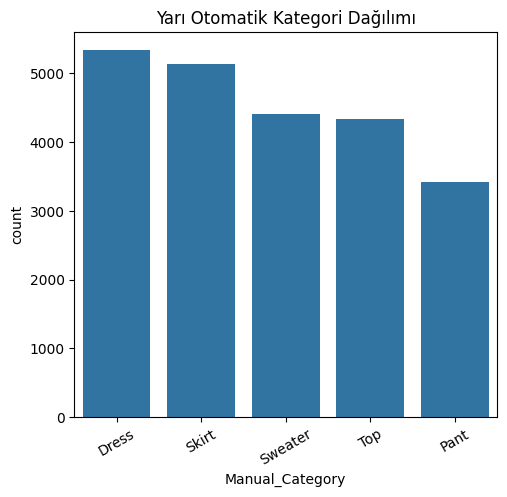

In [41]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Manual_Category', order=df['Manual_Category'].value_counts().index)
plt.title("Yarı Otomatik Kategori Dağılımı")
plt.xticks(rotation=30)


# Test Manual

In [ ]:

# Text girişi ve buton tanımı
text_input = widgets.Text(
     value='',
     placeholder='Yorumunuzu buraya yazın...',
     description='Yorum:',
     layout=widgets.Layout(width='600px')
)
button = widgets.Button(description="Tahmin Et", button_style='success')
output = widgets.Output()

manual_map = {
    0: "Pant",
    1: "Sweater",
    2: "Dress",
    3: "Top",
    4: "Skirt"
}

# Tahmin fonksiyonu
def predict_cluster(b):
     output.clear_output()
     with output:
         new_text = text_input.value
         if not new_text.strip():
             print("Lütfen bir yorum girin.")
             return

         cleaned = clean_text(new_text)
         embedding = model.encode([cleaned])
         cluster = kmeans.predict(embedding)[0]
         label = manual_map.get(cluster, "Bilinmeyen")

         print(f"Tahmin Edilen Sınıf: {label} (Küme {cluster})")

# Butona tıklanınca tahmin fonksiyonu çalışır
button.on_click(predict_cluster)

# Arayüzü göster
display(text_input, button, output)